/var/folders/cb/vb_vwtjs4lb6ny7_6h2tg1v00000gn/T/ipykernel_95991/2385807148.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at'] = pd.to_datetime(df['user_created_at'], errors='coerce')
/var/folders/cb/vb_vwtjs4lb6ny7_6h2tg1v00000gn/T/ipykernel_95991/2385807148.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


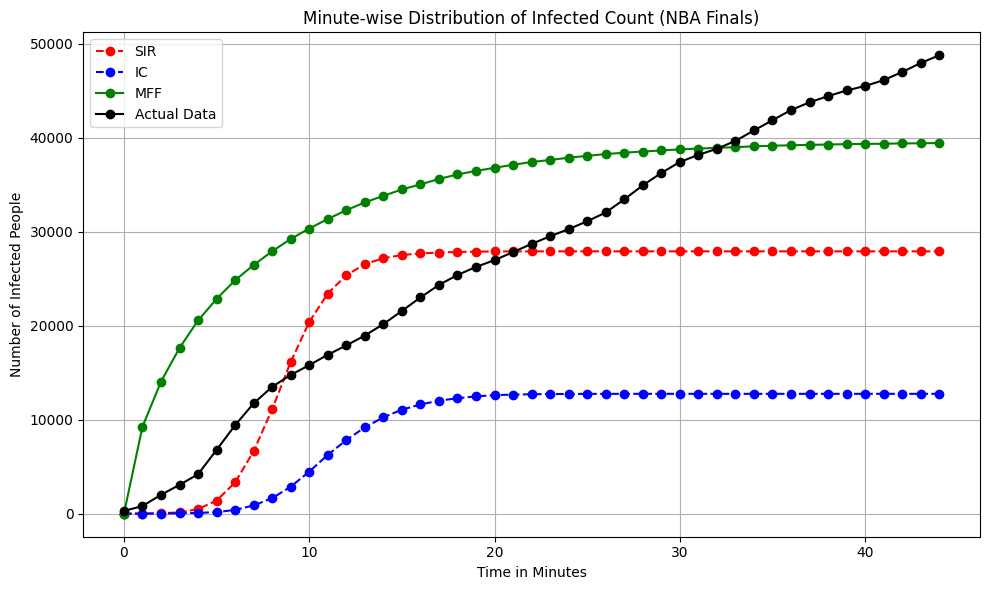

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from datetime import datetime

# === Wczytaj dane ===
df = pd.read_csv("TweetsNBA.csv", encoding="latin1")
df.dropna(subset=['user_id_str'], inplace=True)
df['user_id_str'] = df['user_id_str'].astype(str)
df['user_created_at'] = pd.to_datetime(df['user_created_at'], errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Ogranicz do 1000 użytkowników
sample_users = df['user_id_str'].unique()[:]
df = df[df['user_id_str'].isin(sample_users)]

# === Buduj graf ===
G = nx.DiGraph()
for user in df['user_id_str'].unique():
    G.add_node(user)

for _, row in df.iterrows():
    user = row['user_id_str']
    followers = df['user_id_str'].sample(n=4).tolist()  # gęstszy graf
    for follower in followers:
        if follower != user:
            G.add_edge(user, follower)

# === Parametry wag ===
w1, w2 = 0.5, 0.5
w_IM, w_SS, w_UA, w_TS = 0.25, 0.3, 0.2, 0.25
f0, r0 = 0.5, 0.5

# === Pomocnicze funkcje ===
def calculate_UA(row):
    try:
        days = (datetime.now() - row['user_created_at']).days
        return row['statuses_count'] / days if days > 0 else 0
    except:
        return 0

def assign_TS(text):
    return 4 if "#NBAFinals" in str(text) else 2

def is_mentioned():
    return random.choice([0, 1])

def similarity_score(u, v):
    loc_sim = 1 if u['location'] == v['location'] else 0
    lang_sim = 1 if u['user_lang'] == v['user_lang'] else 0
    return (loc_sim + lang_sim) / 2

# === MFF ===
status = {n: "Tree" for n in G.nodes()}
S, NS = set(), set()
mff_counts = []

for u in G.nodes():
    try:
        u_info = df[df['user_id_str'] == u].iloc[0]
    except:
        continue

    UA_u = calculate_UA(u_info)
    TS_u = assign_TS(u_info['text'])
    fu = w1 * UA_u + w2 * TS_u

    if status[u] == "Tree" and fu >= f0:
        status[u] = "Fire"
        S.add(u)

    if status[u] == "Fire":
        for v in G.successors(u):
            if status[v] == "Tree":
                try:
                    v_info = df[df['user_id_str'] == v].iloc[0]
                except:
                    continue
                UA_v = calculate_UA(v_info)
                TS_v = assign_TS(v_info['text'])
                IM = is_mentioned()
                SS = similarity_score(u_info, v_info)
                ru = w_IM * IM + w_SS * SS + w_UA * UA_v + w_TS * TS_v
                if ru >= r0:
                    status[v] = "Fire"
                    S.add(v)
                else:
                    status[v] = "Burnt"
                    NS.add(v)
    mff_counts.append(len(S) + len(NS))  # zainfekowani = Fire + Burnt

# === Actual data (infected count = tweeterzy + retweeterzy) ===
df_sorted = df.sort_values('created_at')
df_sorted['minute'] = df_sorted['created_at'].dt.floor('min')
actual_series = df_sorted.groupby('minute')['user_id_str'].nunique().cumsum()
actual_list = actual_series.tolist()

# === IC ===
infected_ic = set(random.sample(list(G.nodes()), 10))
all_infected_ic = set(infected_ic)
ic_spread = []

for t in range(45):
    new_infected = set()
    for u in infected_ic:
        for v in G.successors(u):
            if v not in all_infected_ic and random.random() <= 0.2:
                new_infected.add(v)
    infected_ic = new_infected
    all_infected_ic.update(new_infected)
    ic_spread.append(len(all_infected_ic))  # wszyscy zainfekowani

# === SIR ===
sir_status = {n: "S" for n in G.nodes()}
infected_sir = set(random.sample(list(G.nodes()), 10))
sir_timers = {u: 2 for u in infected_sir}
sir_spread = []

for u in infected_sir:
    sir_status[u] = "I"

for t in range(45):
    new_infected = set()
    to_recover = set()
    for u in list(infected_sir):
        for v in G.successors(u):
            if sir_status[v] == "S" and random.random() <= 0.2:
                sir_status[v] = "I"
                new_infected.add(v)
        sir_timers[u] -= 1
        if sir_timers[u] <= 0:
            to_recover.add(u)

    for u in to_recover:
        sir_status[u] = "R"
        infected_sir.remove(u)
        del sir_timers[u]

    for u in new_infected:
        infected_sir.add(u)
        sir_timers[u] = 2

    count = sum(1 for s in sir_status.values() if s in {"I", "R"})
    sir_spread.append(count)

# === Interpolacja i dopasowanie długości ===
max_minutes = 45
time = list(range(max_minutes))

mff_interp = np.interp(time, np.linspace(0, max_minutes, len(mff_counts)), mff_counts)
def fit(data):
    return data + [data[-1]] * (max_minutes - len(data)) if len(data) < max_minutes else data[:max_minutes]

actual_fit = fit(actual_list)
ic_fit = fit(ic_spread)
sir_fit = fit(sir_spread)

# === Wykres ===
plt.figure(figsize=(10, 6))
plt.plot(time, sir_fit, label="SIR", color="red", linestyle="--", marker='o')
plt.plot(time, ic_fit, label="IC", color="blue", linestyle="--", marker='o')
plt.plot(time, mff_interp, label="MFF", color="green", linestyle="-", marker='o')
plt.plot(time, actual_fit, label="Actual Data", color="black", linestyle="-", marker='o')
plt.xlabel("Time in Minutes")
plt.ylabel("Number of Infected People")
plt.title("Minute-wise Distribution of Infected Count (NBA Finals)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/cb/vb_vwtjs4lb6ny7_6h2tg1v00000gn/T/ipykernel_95991/4171163016.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at'] = pd.to_datetime(df['user_created_at'], errors='coerce')
/var/folders/cb/vb_vwtjs4lb6ny7_6h2tg1v00000gn/T/ipykernel_95991/4171163016.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


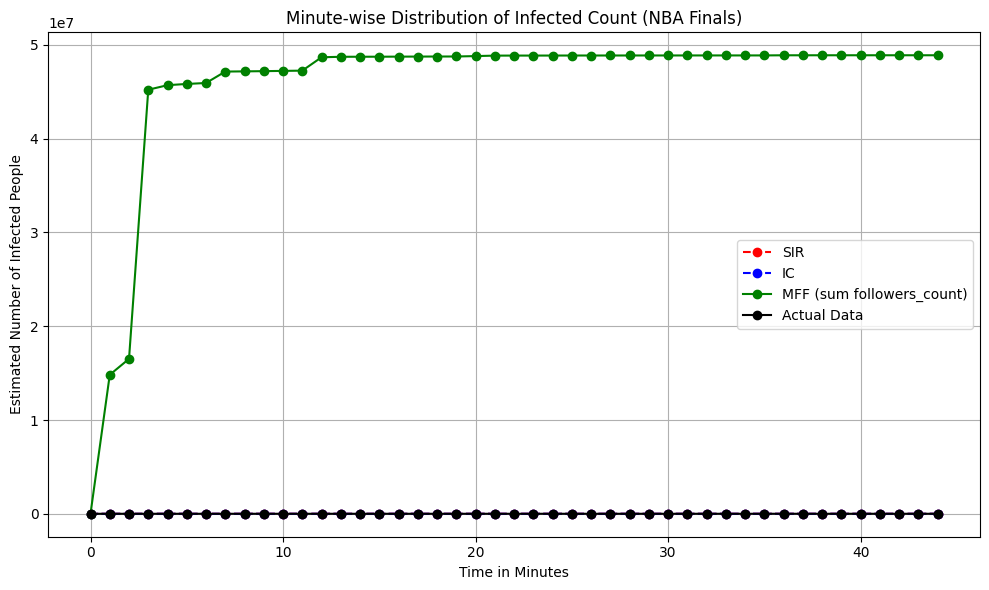

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from datetime import datetime

# === Wczytaj dane ===
df = pd.read_csv("TweetsNBA.csv", encoding="latin1")
df.dropna(subset=['user_id_str'], inplace=True)
df['user_id_str'] = df['user_id_str'].astype(str)
df['user_created_at'] = pd.to_datetime(df['user_created_at'], errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Ogranicz do 1000 użytkowników
sample_users = df['user_id_str'].unique()[:1000]
df = df[df['user_id_str'].isin(sample_users)]

# === Buduj graf (nie używamy go do zainfekowanych, ale dla porównania IC/SIR) ===
G = nx.DiGraph()
for user in df['user_id_str'].unique():
    G.add_node(user)

for _, row in df.iterrows():
    user = row['user_id_str']
    followers = df['user_id_str'].sample(n=4).tolist()
    for follower in followers:
        if follower != user:
            G.add_edge(user, follower)

# === Parametry wag ===
w1, w2 = 0.5, 0.5
w_IM, w_SS, w_UA, w_TS = 0.25, 0.3, 0.2, 0.25
f0, r0 = 0.5, 0.5

# === Pomocnicze funkcje ===
def calculate_UA(row):
    try:
        days = (datetime.now() - row['user_created_at']).days
        return row['statuses_count'] / days if days > 0 else 0
    except:
        return 0

def assign_TS(text):
    return 4 if "#NBAFinals" in str(text) else 2

def is_mentioned():
    return random.choice([0, 1])

def similarity_score(u, v):
    loc_sim = 1 if u['location'] == v['location'] else 0
    lang_sim = 1 if u['user_lang'] == v['user_lang'] else 0
    return (loc_sim + lang_sim) / 2

# === MFF ===
status = {n: "Tree" for n in G.nodes()}
S, NS = set(), set()
mff_counts = []

for u in G.nodes():
    try:
        u_info = df[df['user_id_str'] == u].iloc[0]
    except:
        continue

    UA_u = calculate_UA(u_info)
    TS_u = assign_TS(u_info['text'])
    fu = w1 * UA_u + w2 * TS_u

    if status[u] == "Tree" and fu >= f0:
        status[u] = "Fire"
        S.add(u)

    if status[u] == "Fire":
        for v in G.successors(u):
            if status[v] == "Tree":
                try:
                    v_info = df[df['user_id_str'] == v].iloc[0]
                except:
                    continue
                UA_v = calculate_UA(v_info)
                TS_v = assign_TS(v_info['text'])
                IM = is_mentioned()
                SS = similarity_score(u_info, v_info)
                ru = w_IM * IM + w_SS * SS + w_UA * UA_v + w_TS * TS_v
                if ru >= r0:
                    status[v] = "Fire"
                    S.add(v)
                else:
                    status[v] = "Burnt"
                    NS.add(v)

    # NOWA METODA: liczenie liczby followersów Fire-userów
    infected_count = 0
    for u_fire in S:
        try:
            u_info = df[df['user_id_str'] == u_fire].iloc[0]
            infected_count += u_info['followers_count']
        except:
            continue
    mff_counts.append(infected_count)

# === Actual data ===
df_sorted = df.sort_values('created_at')
df_sorted['minute'] = df_sorted['created_at'].dt.floor('min')
actual_series = df_sorted.groupby('minute')['user_id_str'].nunique().cumsum()
actual_list = actual_series.tolist()

# === IC ===
infected_ic = set(random.sample(list(G.nodes()), 10))
all_infected_ic = set(infected_ic)
ic_spread = []

for t in range(45):
    new_infected = set()
    for u in infected_ic:
        for v in G.successors(u):
            if v not in all_infected_ic and random.random() <= 0.2:
                new_infected.add(v)
    infected_ic = new_infected
    all_infected_ic.update(new_infected)
    ic_spread.append(len(all_infected_ic))

# === SIR ===
sir_status = {n: "S" for n in G.nodes()}
infected_sir = set(random.sample(list(G.nodes()), 10))
sir_timers = {u: 2 for u in infected_sir}
sir_spread = []

for u in infected_sir:
    sir_status[u] = "I"

for t in range(45):
    new_infected = set()
    to_recover = set()
    for u in list(infected_sir):
        for v in G.successors(u):
            if sir_status[v] == "S" and random.random() <= 0.2:
                sir_status[v] = "I"
                new_infected.add(v)
        sir_timers[u] -= 1
        if sir_timers[u] <= 0:
            to_recover.add(u)

    for u in to_recover:
        sir_status[u] = "R"
        infected_sir.remove(u)
        del sir_timers[u]

    for u in new_infected:
        infected_sir.add(u)
        sir_timers[u] = 2

    count = sum(1 for s in sir_status.values() if s in {"I", "R"})
    sir_spread.append(count)

# === Dopasowanie długości ===
max_minutes = 45
time = list(range(max_minutes))

mff_interp = np.interp(time, np.linspace(0, max_minutes, len(mff_counts)), mff_counts)
def fit(data):
    return data + [data[-1]] * (max_minutes - len(data)) if len(data) < max_minutes else data[:max_minutes]

actual_fit = fit(actual_list)
ic_fit = fit(ic_spread)
sir_fit = fit(sir_spread)

# === Wykres ===
plt.figure(figsize=(10, 6))
plt.plot(time, sir_fit, label="SIR", color="red", linestyle="--", marker='o')
plt.plot(time, ic_fit, label="IC", color="blue", linestyle="--", marker='o')
plt.plot(time, mff_interp, label="MFF (sum followers_count)", color="green", linestyle="-", marker='o')
plt.plot(time, actual_fit, label="Actual Data", color="black", linestyle="-", marker='o')
plt.xlabel("Time in Minutes")
plt.ylabel("Estimated Number of Infected People")
plt.title("Minute-wise Distribution of Infected Count (NBA Finals)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
